# Section 4.2


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

from utils.log_print import LogPrint
from configs.base.env_cfg import device, torch_dtype
from utils.model_saver import (
    load_market_and_critic0,
    load_actor,
    load_critic_lambda
)
from utils.pricing.pvv_bs_model import PVVBSModel
from src.bs_model import sim_bs_paths_cfg

from src.data_processing import make_state_t
from src.rl_models import extract_theta_from_outputs

In [2]:
# =============================================================================
# Configuration
# =============================================================================

LOAD_DIR = "models/bs_0_2_mu_0_3"
LOAD_DIR = "models/4_2_bs_0_2"
ACTOR_LAMBDA = 100000.0

# Moneyness and maturity cross-sections
S_OVER_K_GRID = [0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2]
TAU_GRID = [0.05, 0.10, 0.25, 0.50]
LAMBDA_GRID = [
    0.1, 1.0, 10.0, 20.0,
               # 1000000.0
]

In [3]:
# =============================================================================
# Load market, actor, critic0
# =============================================================================
log_print = LogPrint(
    print_debug=True,
    save_dir=os.path.join(LOAD_DIR, "logs"),
    prefix="analysis_section_4_1",
)
critic0, market_cfg, critic0_cfg, runtime_cfg = load_market_and_critic0(
    log_print=log_print,
    load_dir=LOAD_DIR,
    device=device,
    torch_dtype=torch_dtype,
)

actor, actor_cfg = load_actor(
    log_print=log_print,
    load_dir=LOAD_DIR,
    actor_lambda=ACTOR_LAMBDA,
    device=device,
    torch_dtype=torch_dtype,
)

actor.eval()
for p in actor.parameters():
    p.requires_grad_(False)


当前工作目录：/Users/hy/PycharmProjects/qlbs_rl/analysis
已切换到qlbs_rl根目录：/Users/hy/PycharmProjects/qlbs_rl
[MarketArtifactLoader] Loaded market artifact: 
path            : models/4_2_bs_0_2
  - MarketCFG   : market_cfg.json
  - Critic0     : critic0.pt
  - RuntimeCFG  : runtime_cfg.json

[ActorLoader] Loaded actor λ=100000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/actor.pt
  device: mps, dtype: torch.float32


In [4]:
# ============================================================
# Market config (BS)
# ============================================================

S0 = market_cfg.S0
mu = market_cfg.mu          # risk-neutral: mu = r
r = market_cfg.r
sigma = market_cfg.sigma

T = market_cfg.T
T_steps = market_cfg.T_steps
dt = market_cfg.dt

K = S0
option_type = market_cfg.option_type
transaction_cost_rate = market_cfg.transaction_cost_rate

# ============================================================
# Simulate BS paths
# ============================================================
N_paths = 50

S_paths_t, log_returns, _ = sim_bs_paths_cfg(
    s_cfg=market_cfg,
    N_paths=N_paths,
    T_steps=T_steps,
)

# torch -> numpy
S_paths = S_paths_t.cpu().numpy()

# ============================================================
# tau vector
# ============================================================
tau_vec = T - np.arange(T_steps + 1) * float(dt)
tau_vec = np.maximum(tau_vec, 1e-6)

# ============================================================
# BS benchmark price & delta (PVV)
# ============================================================
bs_pricer = PVVBSModel(market_cfg)

S_mat = S_paths[:, :-1]  # (N, T)
K_mat = np.full_like(S_mat, K)

price_mat, delta_mat_bs = bs_pricer.price_and_delta(
    S_mat=S_mat,
    K_mat=K_mat,
    tau_vec=tau_vec[:-1],
)

# assemble delta paths (including maturity)
delta_paths_bs = np.zeros_like(S_paths)
delta_paths_bs[:, :-1] = delta_mat_bs

if option_type == "call":
    delta_T = (S_paths[:, -1] > K).astype(float)
else:
    delta_T = -(S_paths[:, -1] < K).astype(float)

delta_paths_bs[:, -1] = delta_T
# ============================================================
# Initial option price (BS)
# ============================================================
initial_option_price = price_mat[:, 0].mean()


In [5]:
@torch.no_grad()
def acc_slice(
        actor, critic0, 
        all_critic:list,
        S_path: torch.Tensor,
        K,
        t_path: torch.Tensor,
        device, torch_dtype,
):
    S_over_K = S_path / K
    state = make_state_t(
        S_over_K,
        t_path,
    )
    actions = actor.mean(state)

    all_astar = {
        f'ACC-Critic λ: { str(critic.risk_lambda)}' : critic.a_star(state) * (K / S_path) for critic in all_critic
    }

    # Q0 = critic0(state, actions)
    # Q = critic(state, actions)

    return actions, all_astar

In [6]:
with torch.no_grad():
    all_critic = []
    for lam in LAMBDA_GRID:
        critic, _ = load_critic_lambda(
                log_print=log_print,
                load_dir=LOAD_DIR,
                actor_lambda=ACTOR_LAMBDA,
                critic_lambda=lam,
                device=device,
                torch_dtype=torch_dtype,
        )
        all_critic.append(critic)

[CriticLoader] Loaded critic λ=0.1
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_0.1000.pt
  device: mps
[CriticLoader] Loaded critic λ=1.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_1.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=20.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_20.0000.pt
  device: mps


In [7]:
with torch.no_grad():
    T_mat = (
        torch.tensor(tau_vec[:-1], device=device, dtype=torch_dtype)
        .unsqueeze(0)
        .expand(N_paths, T_steps)
    )
    actions, all_astar_dict = acc_slice(
        actor, critic0, 
        all_critic,
        S_paths_t[:, :-1],
        K,
        T_mat,
        device=device,
        torch_dtype=torch_dtype,
    )


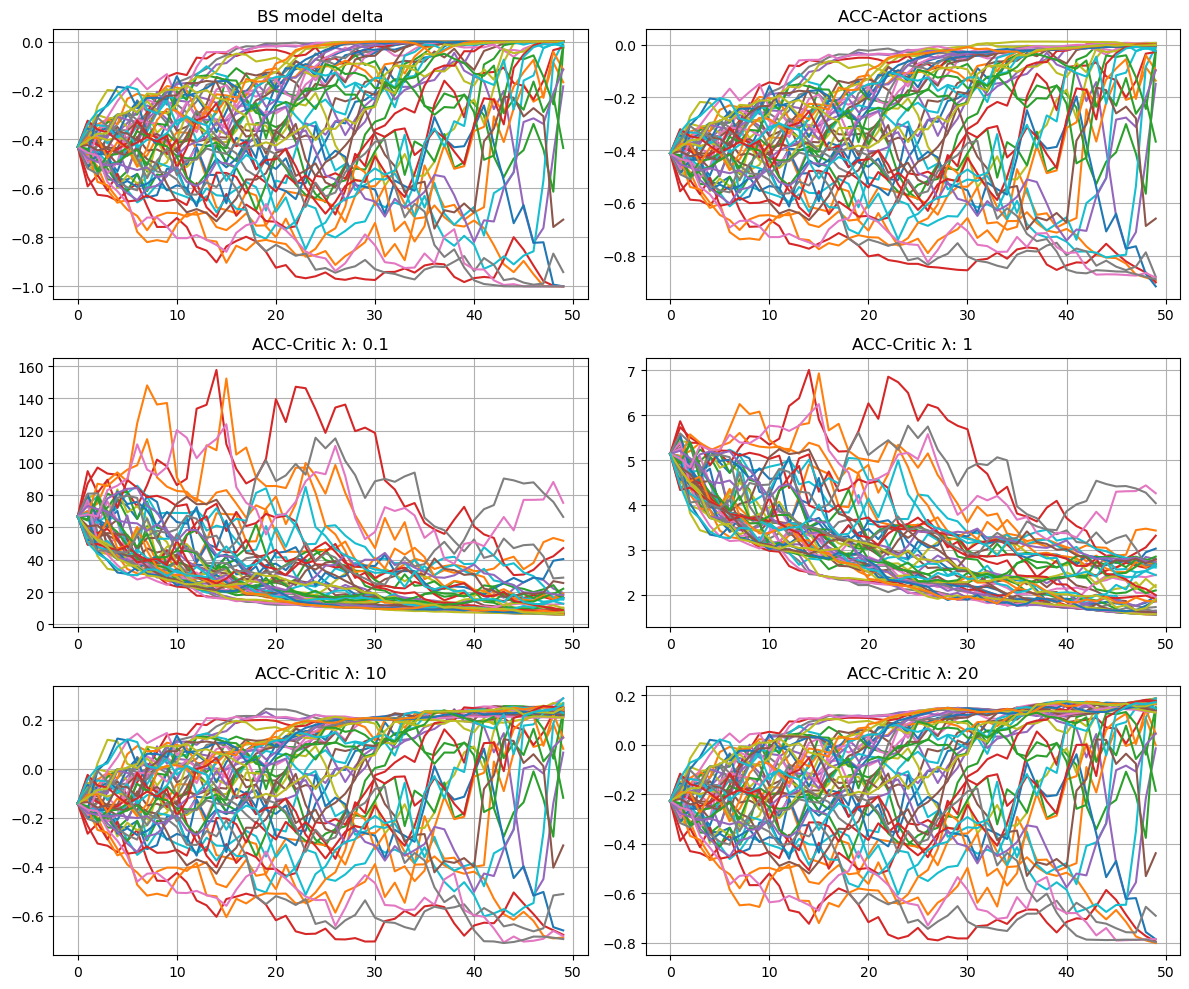

In [8]:

# 模拟你的数据：6个 50×50 的 numpy 数组
all_actions_dict = all_astar_dict.copy()
all_actions_dict['BS model delta'] = delta_paths_bs[:,:-1]
all_actions_dict['ACC-Actor actions'] = actions

first_keys = ['BS model delta', 'ACC-Actor actions']
remaining_keys = [k for k in all_actions_dict.keys() if k not in first_keys]
sorted_keys = first_keys + remaining_keys
# images
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

# 循环字典的名称和数组
for ax, name in zip(axes, sorted_keys):
    arr = all_actions_dict[name]
    if isinstance(arr, torch.Tensor):
        arr = arr.detach().cpu().numpy()
    for row in arr:
        ax.plot(row)
    # 标题用字典的key
    ax.set_title(name)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [9]:
print()